In [9]:
import pandas as pd

1. Load Data Set

In [10]:
df = pd.read_csv("/content/healthcare_dataset.csv")

2. EDA

In [11]:
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (6000, 7)


In [12]:
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [13]:
# Info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 non-null   float64
 4   smoker                   6000 non-null   int64  
 5   blood_pressure           6000 non-null   float64
 6   diabetes                 6000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 328.3 KB


In [14]:
# Missing values
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


In [15]:
df['diabetes'].value_counts()

,count
diabetes,
0,5458
1,542


In [16]:
# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [93]:
# how many smokers have diabetes
df[df['smoker']== 1]['diabetes'].value_counts()

,count
diabetes,
0,1681
1,161


In [94]:
#what about who don't excersice
df[df['exercise_hours_per_week']< df['exercise_hours_per_week'].mean()]['diabetes'].value_counts()

,count
diabetes,
0,2773
1,275


In [96]:
#both
df[(df['exercise_hours_per_week']< df['exercise_hours_per_week'].mean()) & (df['smoker']==1)]['diabetes'].value_counts()

,count
diabetes,
0,846
1,77


4. Data Visualization

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

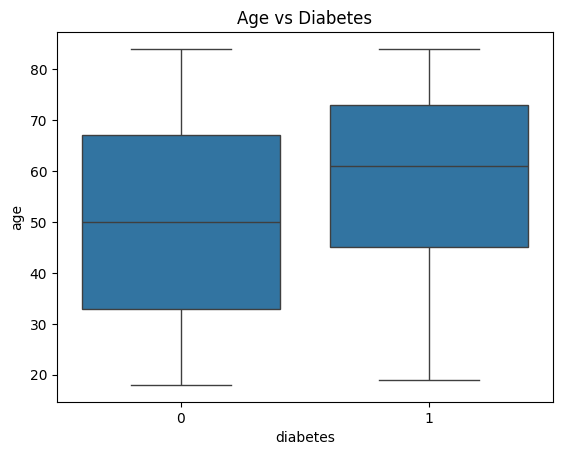

In [19]:
# Age vs Diabetes
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

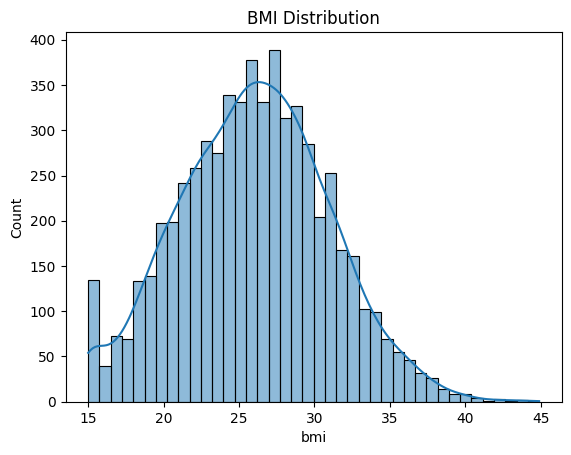

In [20]:
# BMI distribution
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

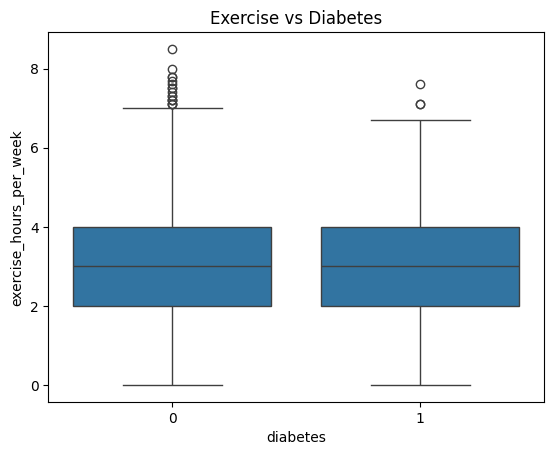

In [21]:
# Exercise vs Diabetes
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

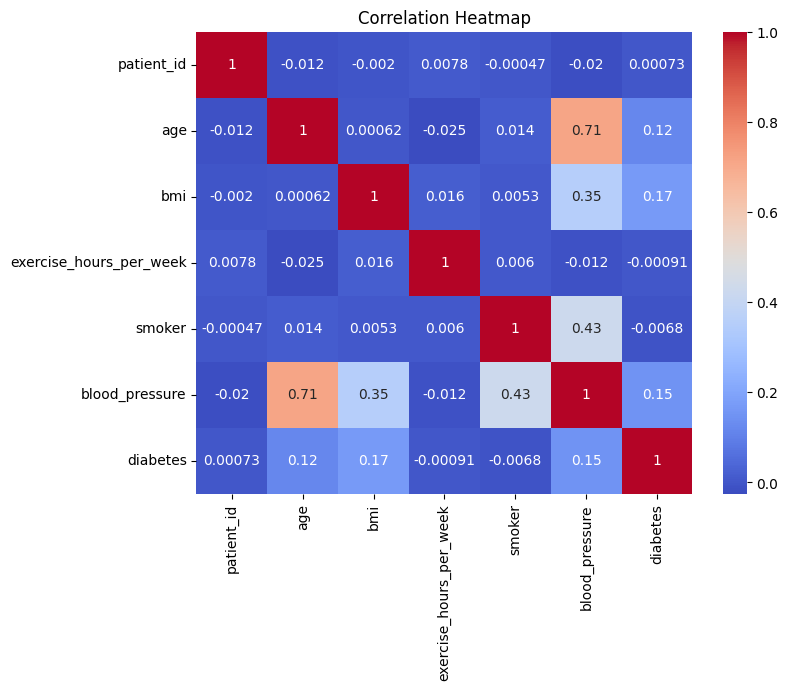

In [22]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Part 2 — Machine Learning Classification Model

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report#, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [59]:
df_d = df[df['diabetes']==0]
df_new = pd.concat([df_d.sample(1500, random_state= 42), df[df['diabetes']==1]])
df_new['diabetes'].value_counts()

,count
diabetes,
0,1500
1,542


In [60]:
# Drop patient_id
#df = df.drop(columns=['patient_id'])

# Features and target
X = df_new.drop(columns=['diabetes'])
y = df_new['diabetes']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Feature scaling
scaler = StandardScaler()
x_train['blood_pressure'] = scaler.fit_transform(x_train[['blood_pressure']])
x_test['blood_pressure'] = scaler.transform(x_test[['blood_pressure']])

In [64]:
lr_model = LogisticRegression(max_iter=100)
lr_model.fit(x_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(x_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(lr_accuracy,2))

Logistic Regression Accuracy: 0.72


In [83]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(x_train, y_train)

# Predictions
y_pred_lr = rf_model.predict(x_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_lr)
print("Random Forest Accuracy:", round(rf_accuracy,2))

Random Forest Accuracy: 0.72


In [86]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Confusion Matrix:
 [[276  26]
 [ 87  20]]


In [87]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.91      0.83       302
           1       0.43      0.19      0.26       107

    accuracy                           0.72       409
   macro avg       0.60      0.55      0.55       409
weighted avg       0.68      0.72      0.68       409



In [88]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

print(feature_importance.sort_values(by='Coefficient', ascending=False))

                   Feature  Coefficient
1                      bmi     0.122880
4           blood_pressure     0.048326
0                      age     0.023492
3                   smoker     0.004478
2  exercise_hours_per_week    -0.020245


# Part 3 — Neural Network Model

In [89]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [90]:
model = Sequential()

# Layers
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6356 - loss: 1.3426 - val_accuracy: 0.7384 - val_loss: 0.6074
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7299 - loss: 0.5920 - val_accuracy: 0.7359 - val_loss: 0.5767
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7287 - loss: 0.5867 - val_accuracy: 0.7384 - val_loss: 0.5833
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7324 - loss: 0.5796 - val_accuracy: 0.7384 - val_loss: 0.5613
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7257 - loss: 0.5812 - val_accuracy: 0.7262 - val_loss: 0.5625
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7177 - loss: 0.5846 - val_accuracy: 0.7311 - val_loss: 0.5612
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7171 - loss: 0.5818 - val_accuracy: 0.7335 - val_loss: 0.5487
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7275 - loss: 0.5606 - val_accuracy: 0.7359 - val_loss: 0.5464
Epo

In [91]:
loss, nn_accuracy = model.evaluate(x_test, y_test)
print("Neural Network Accuracy:", nn_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7384 - loss: 0.5418 
Neural Network Accuracy: 0.738386332988739


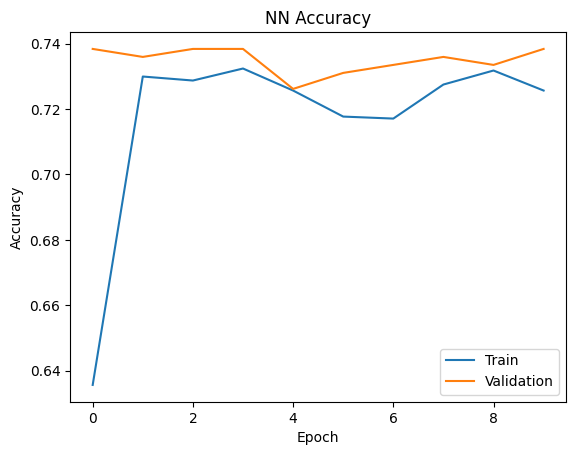

In [92]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()